In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded:", df.shape)

Mounted at /content/drive
Dataset loaded: (48536, 28)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)
Train size: (33975, 26)
Validation size: (4853, 26)
Test size: (9708, 26)
After SMOTE, Train size: (34149, 26)

Training LightGBM for: Motor_Symptoms
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2421
[LightGBM] [Info] Number of data points in the train set: 34149, number of used features: 26
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's multi_logloss: 1.09857

Results:
Accuracy : 0.333539348

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


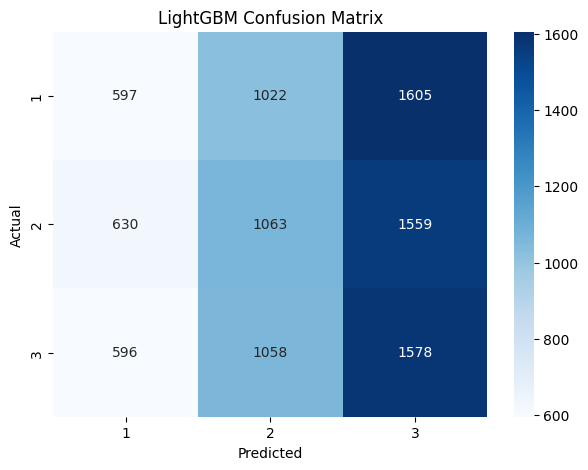

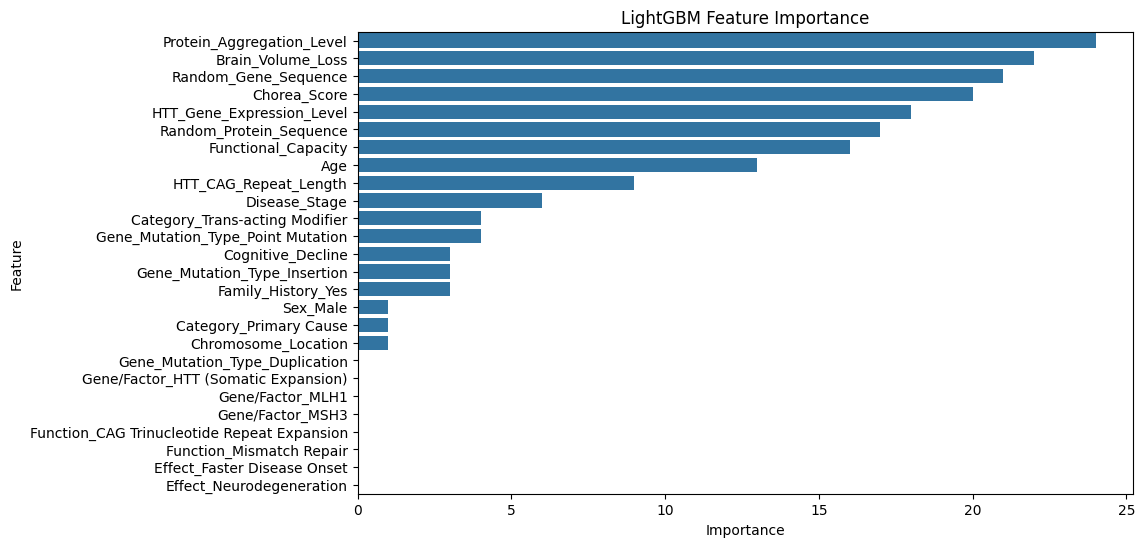

In [ ]:
# ================================
# Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import lightgbm as lgb
from lightgbm import early_stopping
import matplotlib.pyplot as plt
import seaborn as sns

# For oversampling
from imblearn.over_sampling import SMOTE

# ================================
# Mount Google Drive & Load Dataset
# ================================
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# ================================
# Prepare Target
# ================================
target_col = 'Motor_Symptoms'
y = df[target_col].values

# Drop target and leakage columns
leakage_cols = ['Patient_ID', target_col]
X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# ================================
# Train / Val / Test Split
# 70% Train, 10% Validation, 20% Test
# ================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

# ================================
# SMOTE Oversampling to balance classes
# ================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE, Train size:", X_train_res.shape)

# ================================
# Train LightGBM with Tuned Hyperparameters
# ================================
print("\n========================================")
print(f"Training LightGBM for: {target_col}")
print("========================================")

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    n_estimators=1000,       # fewer boosting rounds for speed
    learning_rate=0.05,      # higher learning rate for faster convergence
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    boosting_type='gbdt',    # fast training
    random_state=42,
    class_weight='balanced'
)

# Fit model with early stopping
lgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(stopping_rounds=50)]
)

# ================================
# Prediction
# ================================
y_pred = lgb_model.predict(X_test)

# ================================
# Evaluation
# ================================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Mild', 'Moderate', 'Severe'],
    zero_division=0
))

# ================================
# Confusion Matrix Visualization
# ================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()

# ================================
# Feature Importance
# ================================
importances = lgb_model.feature_importances_
feature_names = df.drop(columns=leakage_cols).columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("LightGBM Feature Importance")
plt.show()


Train size: (33975, 26)
Validation size: (4853, 26)
Test size: (9708, 26)
After SMOTE, Train size: (34408, 26)

Training LightGBM for: Disease_Stage
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009585 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3889
[LightGBM] [Info] Number of data points in the train set: 34408, number of used features: 26
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's multi_logloss: 1.38633

Results:
Accuracy : 0.2477338277709106
Precision: 0.24797468881496884
Recall   : 0.2477338277709106
F1-score : 0.2466963592880642

Classification Re

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


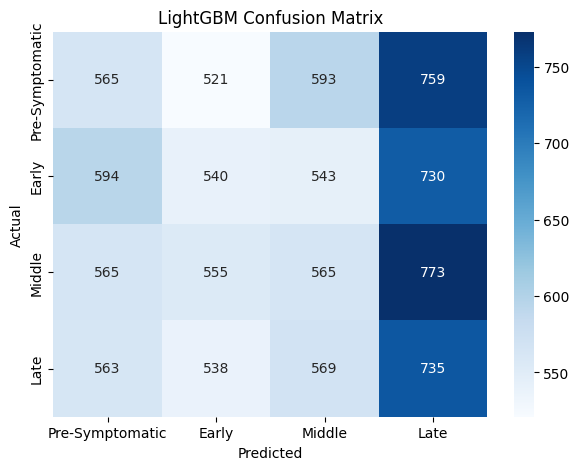

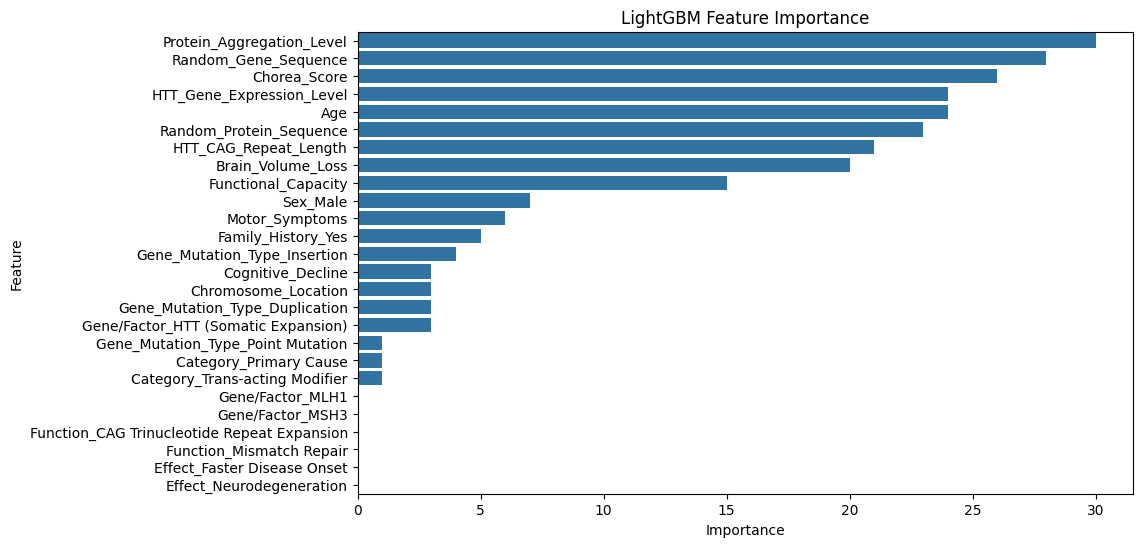

In [ ]:
# ================================
# Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import lightgbm as lgb
from lightgbm import early_stopping
import matplotlib.pyplot as plt
import seaborn as sns

# For oversampling
from imblearn.over_sampling import SMOTE


# ================================
# Prepare Target
# ================================
target_col = 'Disease_Stage'
y = df[target_col].values

# Drop target and leakage columns
leakage_cols = ['Patient_ID', target_col]
X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# ================================
# Train / Validation / Test Split
# 70% Train, 10% Validation, 20% Test
# ================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

# ================================
# SMOTE Oversampling to balance classes
# ================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE, Train size:", X_train_res.shape)

# ================================
# Train LightGBM with Tuned Hyperparameters
# ================================
print("\n========================================")
print(f"Training LightGBM for: {target_col}")
print("========================================")

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),  # 4 classes
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    boosting_type='gbdt',
    random_state=42,
    class_weight='balanced'
)

# Fit model with early stopping
lgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(stopping_rounds=50)]
)

# ================================
# Prediction
# ================================
y_pred = lgb_model.predict(X_test)

# ================================
# Evaluation
# ================================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

stage_labels = ['Pre-Symptomatic', 'Early', 'Middle', 'Late']

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=stage_labels,
    zero_division=0
))

# ================================
# Confusion Matrix Visualization
# ================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_labels,
            yticklabels=stage_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()

# ================================
# Feature Importance
# ================================
importances = lgb_model.feature_importances_
feature_names = df.drop(columns=leakage_cols).columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("LightGBM Feature Importance")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)


/tmp/ipython-input-46017176.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipython-input-46017176.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipython-input-46017176.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

Train size: (33975, 23)
Validation size: (4853, 23)
Test size: (9708, 23)
After SMOTE, Train size: (50985, 23)

Training LightGBM for: Category
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3834
[LightGBM] [Info] Number of data points in the train set: 50985, number of used features: 23
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Results:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      2406
Trans-acting Modifier       1.00      1.00      1.00      2446
  Cis-acting Modifier       1.00      1.00      1.00      4856

             accuracy                           1.00      9708
            macro avg       1.00      1.00      1.00      9708
         weighted avg       1.00      1.00      1.00      9708



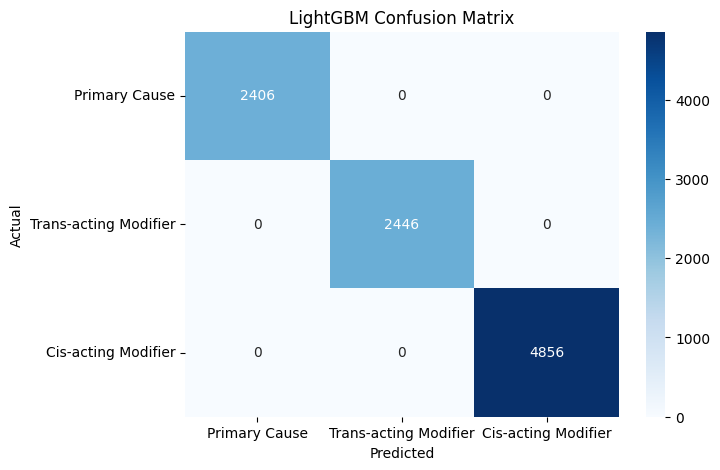

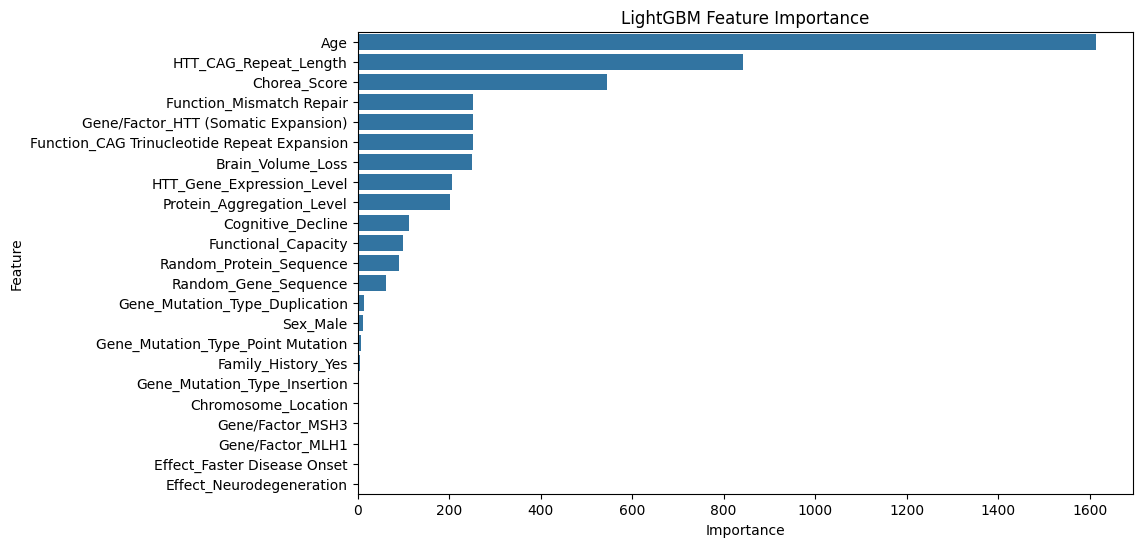

In [ ]:
# ================================
# Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import lightgbm as lgb
from lightgbm import early_stopping
import matplotlib.pyplot as plt
import seaborn as sns

# For oversampling
from imblearn.over_sampling import SMOTE

# ================================
# Mount Google Drive & Load Dataset
# ================================
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)
print("Dataset loaded successfully:", df.shape)

# ================================
# Reconstruct Category Target
# ================================
def get_category(row):
    if row['Category_Primary Cause'] == 1:
        return 'Primary Cause'
    elif row['Category_Trans-acting Modifier'] == 1:
        return 'Trans-acting Modifier'
    else:  # dropped Cis-acting Modifier
        return 'Cis-acting Modifier'

df['Category'] = df.apply(get_category, axis=1)

# ================================
# Prepare Features and Target
# ================================
target_col = 'Category'
y = df[target_col].values

# Exclude one-hot columns from features
feature_cols = [col for col in df.columns if col not in ['Category_Primary Cause',
                                                        'Category_Trans-acting Modifier',
                                                        'Cis-acting Modifier',
                                                        'Category', 'Patient_ID', 'Disease_Stage', 'Motor_Symptoms']]

X = df[feature_cols]

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# ================================
# Train / Validation / Test Split
# 70% Train, 10% Validation, 20% Test
# ================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

# ================================
# SMOTE Oversampling
# ================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE, Train size:", X_train_res.shape)

# ================================
# Train LightGBM
# ================================
print("\n========================================")
print(f"Training LightGBM for: {target_col}")
print("========================================")

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    boosting_type='gbdt',
    random_state=42,
    class_weight='balanced'
)

lgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(stopping_rounds=50)]
)

# ================================
# Prediction & Evaluation
# ================================
y_pred = lgb_model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

category_labels = ['Primary Cause', 'Trans-acting Modifier', 'Cis-acting Modifier']

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=category_labels,
    zero_division=0
))

# ================================
# Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_labels,
            yticklabels=category_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()

# ================================
# Feature Importance
# ================================
importances = lgb_model.feature_importances_
feature_names = [col for col in df.columns if col not in ['Category_Primary Cause',
                                                          'Category_Trans-acting Modifier',
                                                          'Cis-acting Modifier',
                                                          'Category', 'Patient_ID', 'Disease_Stage', 'Motor_Symptoms']]

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("LightGBM Feature Importance")
plt.show()
